In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("HR_Attrition_Case_Study.csv")

print(f"Number of items is: {df.shape[0]}, number of columns is: {df.shape[1]}")
print("Column names are:")
print(df.columns.tolist())

df.head()
df.info()

df.isnull().sum()


Number of items is: 14999, number of columns is: 10
Column names are:
['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'sales', 'salary']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), in

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

In [3]:
print(f"Number of duplicate items: {df.duplicated().sum()}")

print(df['sales'].unique())
print(df['salary'].unique())


df.describe()


Number of duplicate items: 3008
['sales' 'accounting' 'hr' 'technical' 'support' 'management' 'IT'
 'product_mng' 'marketing' 'RandD']
['low' 'medium' 'high']


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000,14999.000000
mean,0.612834,0.716102,3.803054,201.050337,3.498233,0.144610,0.238083,0.021268
std,0.248631,0.171169,1.232592,49.943099,1.460136,0.351719,0.425924,0.144281
min,0.090000,0.360000,2.000000,96.000000,2.000000,0.000000,0.000000,0.000000
25%,0.440000,0.560000,3.000000,156.000000,3.000000,0.000000,0.000000,0.000000
50%,0.640000,0.720000,4.000000,200.000000,3.000000,0.000000,0.000000,0.000000
75%,0.820000,0.870000,5.000000,245.000000,4.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,7.000000,310.000000,10.000000,1.000000,1.000000,1.000000


In [4]:
df_clean = df.drop_duplicates()
print("Shape after removing duplicates:", df_clean.shape)

df_clean = df_clean.rename(columns={'sales': 'department'})


salary_order = ['low', 'medium', 'high']
df_clean['salary'] = pd.Categorical(df_clean['salary'], categories=salary_order, ordered=True)

df_clean.info()
df_clean.head()

Shape after removing duplicates: (11991, 10)
<class 'pandas.core.frame.DataFrame'>
Index: 11991 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   satisfaction_level     11991 non-null  float64 
 1   last_evaluation        11991 non-null  float64 
 2   number_project         11991 non-null  int64   
 3   average_montly_hours   11991 non-null  int64   
 4   time_spend_company     11991 non-null  int64   
 5   Work_accident          11991 non-null  int64   
 6   left                   11991 non-null  int64   
 7   promotion_last_5years  11991 non-null  int64   
 8   department             11991 non-null  object  
 9   salary                 11991 non-null  category
dtypes: category(1), float64(2), int64(6), object(1)
memory usage: 948.6+ KB


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [5]:
df_clean = df_clean.reset_index(drop=True)

department
hr             0.188020
accounting     0.175523
technical      0.173797
support        0.171334
sales          0.169805
marketing      0.166419
IT             0.161885
product_mng    0.160350
RandD          0.122478
management     0.119266
Name: left, dtype: float64


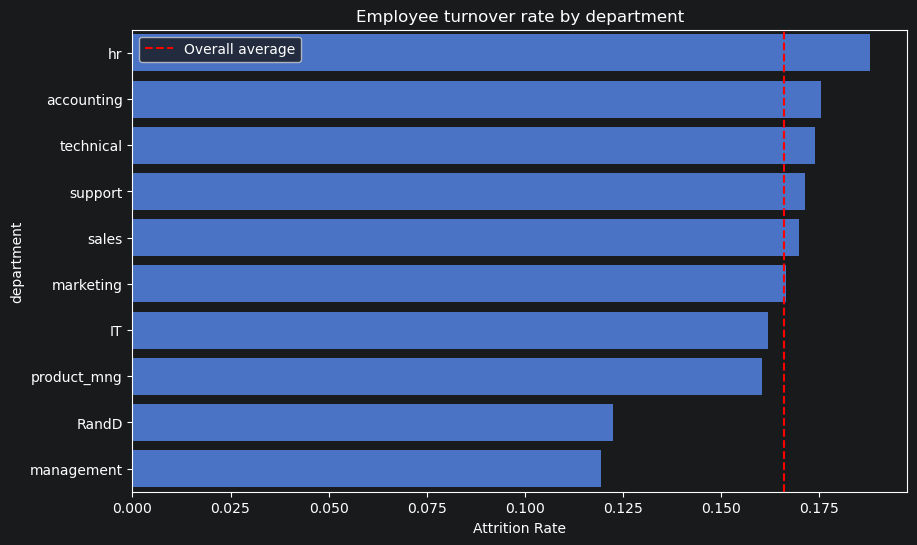

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

dept_attrition = df_clean.groupby('department')['left'].mean().sort_values(ascending=False)
print(dept_attrition)

plt.figure(figsize=(10, 6))
sns.barplot(x=dept_attrition.values, y=dept_attrition.index, orient='h')
plt.xlabel('Attrition Rate')
plt.title('Employee turnover rate by department')
plt.axvline(df_clean['left'].mean(), color='red', linestyle='--', label='Overall average')
plt.legend()
plt.show()

In [7]:
dept_counts = df_clean['department'].value_counts()
print(dept_counts)

summary = pd.DataFrame({
    'attrition_rate': dept_attrition,
    'employee_count': dept_counts
}).sort_values('attrition_rate', ascending=False)
print(summary)

print("Overall attrition rate (cleaned data):", df_clean['left'].mean())

department
sales          3239
technical      2244
support        1821
IT              976
RandD           694
product_mng     686
marketing       673
accounting      621
hr              601
management      436
Name: count, dtype: int64
             attrition_rate  employee_count
department                                 
hr                 0.188020             601
accounting         0.175523             621
technical          0.173797            2244
support            0.171334            1821
sales              0.169805            3239
marketing          0.166419             673
IT                 0.161885             976
product_mng        0.160350             686
RandD              0.122478             694
management         0.119266             436
Overall attrition rate (cleaned data): 0.1660411975648403


salary
low       0.204530
medium    0.146170
high      0.048485
Name: left, dtype: float64
salary
low       5740
medium    5261
high       990
Name: count, dtype: int64


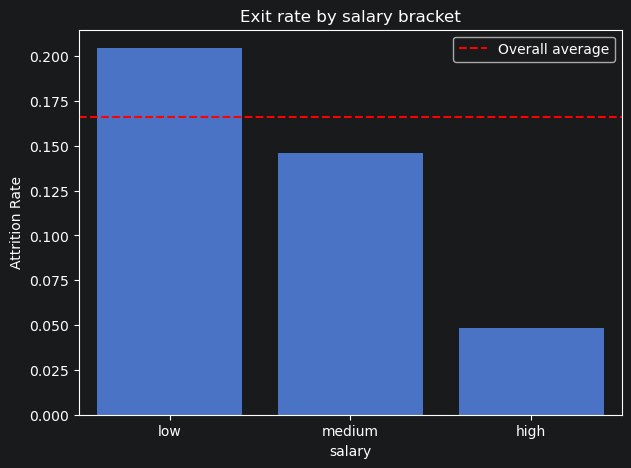

In [10]:
salary_attrition = df_clean.groupby('salary', observed=True)['left'].mean()
print(salary_attrition)

salary_counts = df_clean['salary'].value_counts()
print(salary_counts)

plt.figure(figsize=(7, 5))
sns.barplot(x=salary_attrition.index, y=salary_attrition.values, order=['low', 'medium', 'high'])
plt.ylabel('Attrition Rate')
plt.title('Exit rate by salary bracket')
plt.axhline(df_clean['left'].mean(), color='red', linestyle='--', label='Overall average')
plt.legend()
plt.show()

number_project
2    0.541719
3    0.010795
4    0.064315
5    0.153605
6    0.449153
7    1.000000
Name: left, dtype: float64
number_project
2    1582
3    3520
4    3685
5    2233
6     826
7     145
Name: count, dtype: int64


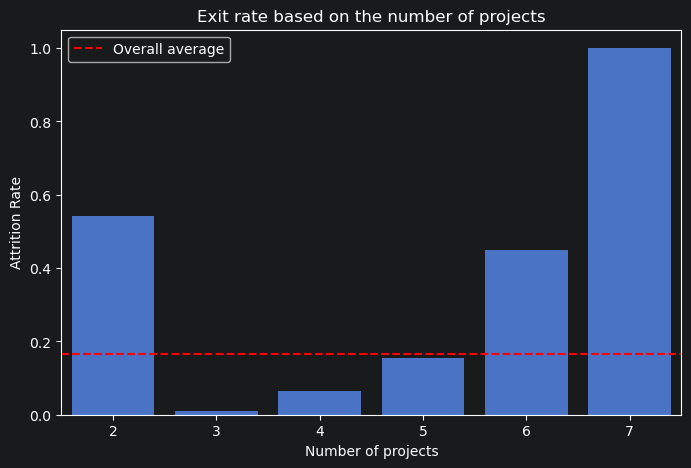

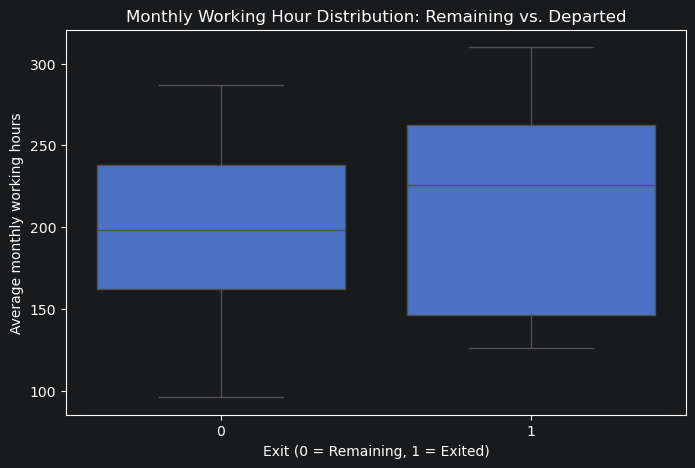

In [11]:
project_attrition = df_clean.groupby('number_project')['left'].mean()
print(project_attrition)

project_counts = df_clean['number_project'].value_counts().sort_index()
print(project_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=project_attrition.index, y=project_attrition.values)
plt.ylabel('Attrition Rate')
plt.xlabel('Number of projects')
plt.axhline(df_clean['left'].mean(), color='red', linestyle='--', label='Overall average')
plt.legend()
plt.title('Exit rate based on the number of projects')
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='left', y='average_montly_hours', data=df_clean)
plt.xlabel('Exit (0 = Remaining, 1 = Exited)')
plt.ylabel('Average monthly working hours')
plt.title('Monthly Working Hour Distribution: Remaining vs. Departed')
plt.show()

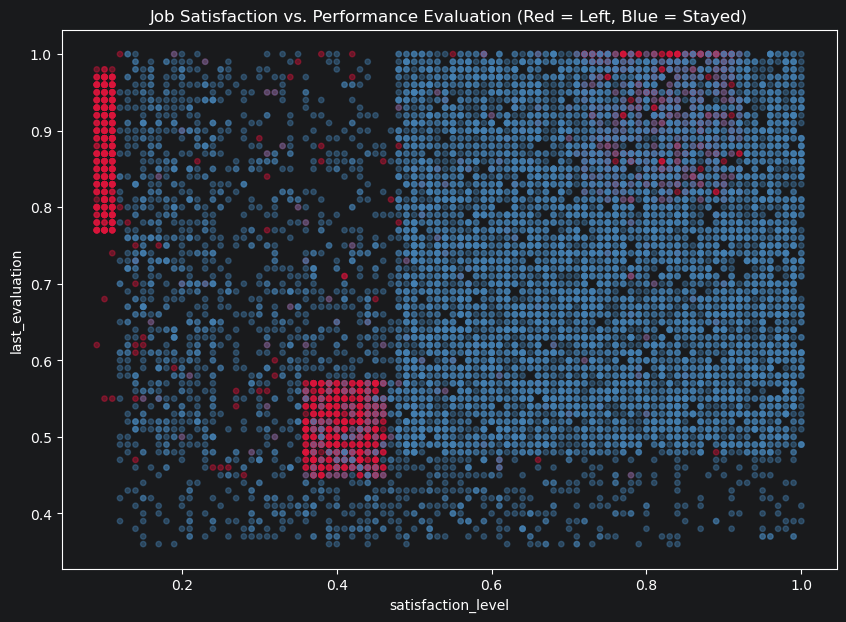

In [12]:
plt.figure(figsize=(10, 7))
colors = df_clean['left'].map({0: 'steelblue', 1: 'crimson'})
plt.scatter(df_clean['satisfaction_level'], df_clean['last_evaluation'],
            c=colors, alpha=0.4, s=15)
plt.xlabel('satisfaction_level')
plt.ylabel('last_evaluation')
plt.title('Job Satisfaction vs. Performance Evaluation (Red = Left, Blue = Stayed)')
plt.show()

Promotion vs Attrition:
 promotion_last_5years
0    0.168222
1    0.039409
Name: left, dtype: float64

Promotion vs Satisfaction:
 promotion_last_5years
0    0.629032
1    0.666010
Name: satisfaction_level, dtype: float64

Tenure vs Satisfaction:
 time_spend_company
2     0.699165
3     0.648988
4     0.516090
5     0.583183
6     0.571107
7     0.635957
8     0.665062
10    0.655327
Name: satisfaction_level, dtype: float64

Tenure counts:
 time_spend_company
2     2910
3     5190
4     2005
5     1062
6      542
7       94
8       81
10     107
Name: count, dtype: int64


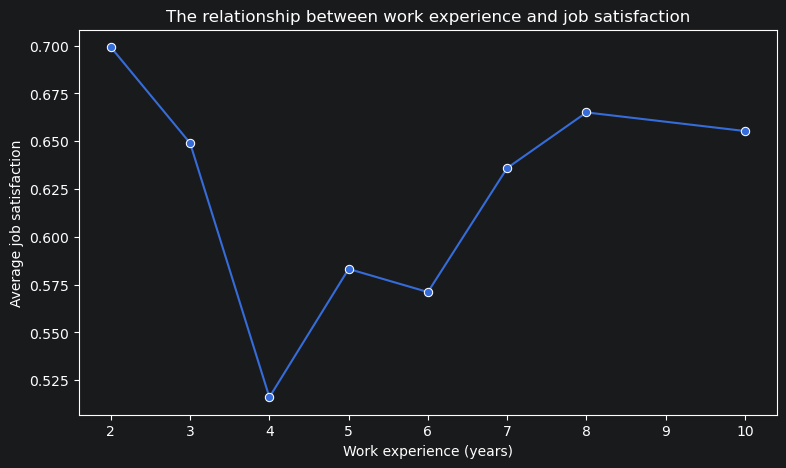

In [13]:
# سؤال ۵: ارتقا و خروج
promo_attrition = df_clean.groupby('promotion_last_5years')['left'].mean()
print("Promotion vs Attrition:\n", promo_attrition)

# سؤال ۶: ارتقا و رضایت
promo_satisfaction = df_clean.groupby('promotion_last_5years')['satisfaction_level'].mean()
print("\nPromotion vs Satisfaction:\n", promo_satisfaction)

# سؤال ۷: سابقه‌ی کار و رضایت
tenure_satisfaction = df_clean.groupby('time_spend_company')['satisfaction_level'].mean()
print("\nTenure vs Satisfaction:\n", tenure_satisfaction)

tenure_counts = df_clean['time_spend_company'].value_counts().sort_index()
print("\nTenure counts:\n", tenure_counts)

plt.figure(figsize=(9, 5))
sns.lineplot(x=tenure_satisfaction.index, y=tenure_satisfaction.values, marker='o')
plt.xlabel('Work experience (years)')
plt.ylabel('Average job satisfaction')
plt.title('The relationship between work experience and job satisfaction')
plt.show()

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

salary_map = {'low': 0, 'medium': 1, 'high': 2}
df_model = df_clean.copy()
df_model['salary_encoded'] = df_model['salary'].map(salary_map)

df_model = pd.get_dummies(df_model, columns=['department'], drop_first=True)

feature_cols = ['satisfaction_level', 'last_evaluation', 'number_project',
                 'average_montly_hours', 'time_spend_company', 'Work_accident',
                 'promotion_last_5years', 'salary_encoded'] + \
                [col for col in df_model.columns if col.startswith('department_')]

X = df_model[feature_cols]
y = df_model['left']

print("Feature columns:", feature_cols)
print("X shape:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Train size:", X_train.shape[0], " Test size:", X_test.shape[0])

Feature columns: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company', 'Work_accident', 'promotion_last_5years', 'salary_encoded', 'department_RandD', 'department_accounting', 'department_hr', 'department_management', 'department_marketing', 'department_product_mng', 'department_sales', 'department_support', 'department_technical']
X shape: (11991, 17)
Train size: 8993  Test size: 2998


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8342228152101401
Precision: 0.5027322404371585
Recall: 0.18473895582329317
F1 Score: 0.2701908957415565

Confusion Matrix:
 [[2409   91]
 [ 406   92]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.96      0.91      2500
           1       0.50      0.18      0.27       498

    accuracy                           0.83      2998
   macro avg       0.68      0.57      0.59      2998
weighted avg       0.80      0.83      0.80      2998



In [16]:
model_balanced = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
model_balanced.fit(X_train_scaled, y_train)

y_pred_balanced = model_balanced.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_balanced))
print("Precision:", precision_score(y_test, y_pred_balanced))
print("Recall:", recall_score(y_test, y_pred_balanced))
print("F1 Score:", f1_score(y_test, y_pred_balanced))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_balanced))

coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': model_balanced.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)
print("\nFeature Importance (by coefficient):\n", coef_df)

Accuracy: 0.7781854569713142
Precision: 0.4150559511698881
Recall: 0.8192771084337349
F1 Score: 0.550979068197164

Confusion Matrix:
 [[1925  575]
 [  90  408]]

Feature Importance (by coefficient):
                    feature  coefficient
0       satisfaction_level    -1.090248
4       time_spend_company     0.882633
2           number_project    -0.535872
5            Work_accident    -0.493252
7           salary_encoded    -0.386559
3     average_montly_hours     0.218213
1          last_evaluation     0.191503
6    promotion_last_5years    -0.148036
8         department_RandD    -0.110591
11   department_management    -0.093955
14        department_sales     0.031543
13  department_product_mng    -0.022222
16    department_technical     0.014678
10           department_hr     0.008085
12    department_marketing    -0.001659
9    department_accounting    -0.001262
15      department_support    -0.000423


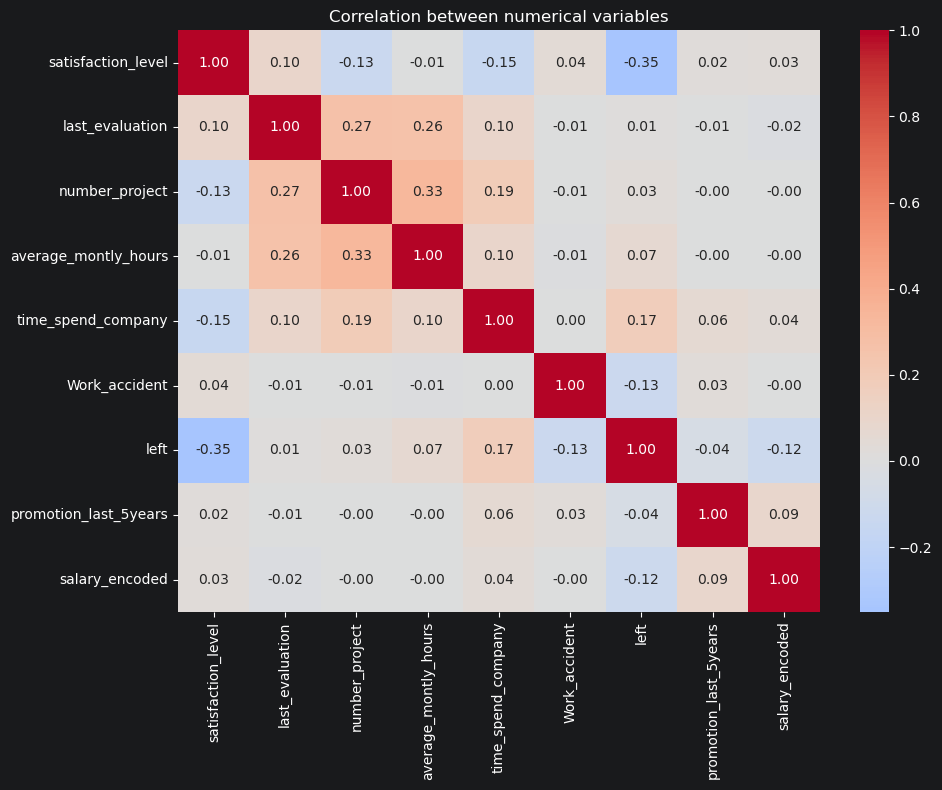

In [17]:
plt.figure(figsize=(10, 8))
corr_cols = ['satisfaction_level', 'last_evaluation', 'number_project',
             'average_montly_hours', 'time_spend_company', 'Work_accident',
             'left', 'promotion_last_5years', 'salary_encoded']
corr_matrix = df_model[corr_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation between numerical variables')
plt.tight_layout()
plt.show()